In [1]:
import pandas as pd

df = pd.read_csv('/content/online_retail_combined.csv')

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (11791, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [2]:
# Select numerical columns automatically
X = df.select_dtypes(include=['int64', 'float64']).copy()

print("Features used for PCA:")
print(X.columns.tolist())

Features used for PCA:
['Quantity', 'Price', 'Customer ID']


In [3]:
X = X.drop(columns=['CustomerID'], errors='ignore')

In [4]:
print("Missing values:")
print(X.isnull().sum())

# Fill missing numerical values with median
X = X.fillna(X.median())

Missing values:
Quantity          0
Price             1
Customer ID    3049
dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")

Standardization completed!


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("New number of features:", X_pca.shape[1])

Original number of features: 3
New number of features: 2


In [7]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.34157616 0.33174636]

Total explained variance:
0.6733225186738327


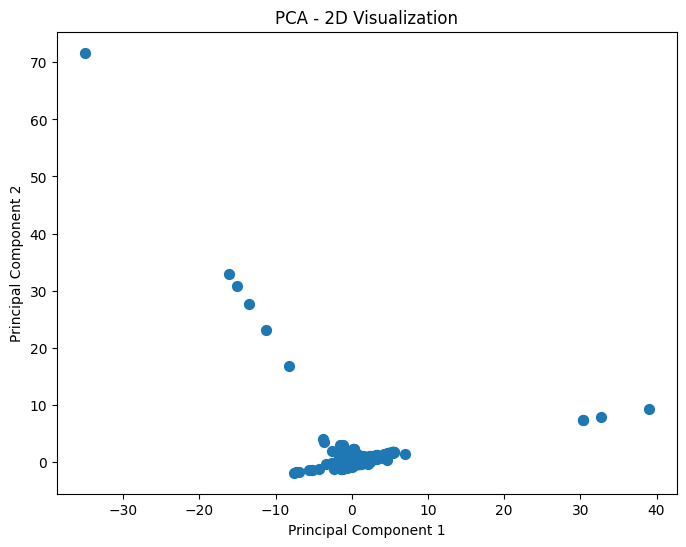

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")

plt.show()

In [9]:
components = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

print(components)

     Quantity     Price  Customer ID
PC1  0.662596 -0.428225     0.614483
PC2  0.150518  0.879825     0.450835


In [10]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print(pca_df.head())

        PC1       PC2
0 -1.110552 -0.690228
1 -1.107051 -0.697420
2 -1.107051 -0.697420
3 -0.762355 -0.804821
4 -0.923018 -0.875263


In [11]:
pca_df.to_csv(
    '/content/online_retail_combined.csv',
    index=False
)

print("PCA result saved successfully!")

PCA result saved successfully!
